# Hyperparameter selection for the paper (LGCP + baselines)

Two fixed test weeks are used throughout — **2025-05-01..07** (spring) and
**2025-11-01..07** (autumn) — instead of searching over which week to use.
For every method, hyperparameters are chosen to maximize a **relative,
week-averaged score**: each metric is min-max normalized *within each week*
(so 1.0 = the best combo that week, 0.0 = the worst, regardless of the
metric's raw scale) before averaging across the two weeks. This matters
because May and November traffic levels differ, so a plain arithmetic
average of raw metrics would let whichever week has larger numbers
dominate the choice.

**Method**

1. Train LGCP with every combination of temporal-kernel structure and
   learning rate, on both weeks (grid defined in the first cell below).
2. Score every (kernel, lr) combo by its relative, week-averaged
   `(mean_ll_obs, rmse_daily)`; a combo only qualifies if it converged on
   *both* weeks. Pick the top scorer.
3. Re-train the winning LGCP config at full training length on both weeks.
4. Grid-search each baseline (window Poisson GLM, GNN, last-available
   Poisson) the same way — same two weeks, same relative-average scoring —
   and take the best configuration per method.
5. Assemble a final comparison table (per week + week-average) for all 4
   methods.

All metrics come from `evaluate_metrics()` in `src/models/metrics_lgcp.py`.

## All hyperparameter grids

Everything that varies across this notebook's searches, in one place.

In [1]:
# --- shared ---
YEARS = [2024, 2025]
SEED = 0

TEST_WEEKS = [
    {"label": "may", "test_start": "2025-05-01", "test_end": "2025-05-07"},
    {"label": "november", "test_start": "2025-11-01", "test_end": "2025-11-07"},
]

# Metrics used for the relative, week-averaged score (see methodology
# markdown cell below). "max" = higher is better, "min" = lower is better.
METRIC_DIRECTIONS = {
    "mean_ll_obs": "max",
    "rmse_daily": "min",
}

# --- LGCP ---
# Covariates: base set + the 4 daily-total/rolling lag features confirmed
# to help (Step 5) -- folded into the base grid here so kernel/lr selection
# accounts for them from the start, rather than as an after-the-fact add-on.
LGCP_COVARIATE_COLS = [
    "chl", "thetao", "fishing_block", "is_holiday", "is_weekend",
    "cell_lag_1", "cell_lag_7",
    "cell_roll_mean_7", "daily_total_lag_1", "daily_total_lag_7", "daily_total_roll_mean_7",
]

LGCP_LR_GRID = [0.0005, 0.001, 0.01]  # 0.05 removed (consistently diverged, see Step 1/8); 0.0005 added

# Temporal-kernel combinations: each is a list of physical periods (days)
# for the periodic components summed with a short-scale RBF. Converted to
# the model's standardized time units per-week (see period_to_std below).
LGCP_KERNEL_SPECS = {
    "weekly": [7.0],
    "monthly": [30.44],
    "yearly": [365.25],
    "weekly+monthly": [7.0, 30.44],
    "weekly+yearly": [7.0, 365.25],
}

# Fixed spatial-kernel lengthscale values tested in Step 6, holding the
# winning (kernel, lr) fixed -- staged after Step 1/2 rather than crossed
# into the main grid, to keep compute bounded.
LGCP_SPATIAL_LENGTHSCALE_GRID = [0.05, 0.1, 0.2, 0.35]

LGCP_NUM_STEPS_SEARCH = 1500   # reduced budget for the grid search
LGCP_NUM_STEPS_FINAL = 5000    # full length, used only for the winning config
LGCP_M_INDUCING = 300
LGCP_NUM_MC = 64   # was 32

# --- Window Poisson GLM ---
GLM_ALPHA_GRID = [1e-4, 1e-3, 1e-2, 1e-1, 1.0]     # standard log-spaced L2 grid
GLM_WINDOW_SIZE_GRID = [3, 7, 14]                    # short / weekly / biweekly context

# --- GNN ---
GNN_HIDDEN_DIM_GRID = [16, 32, 64]
GNN_NUM_LAYERS_GRID = [1, 2, 3]
GNN_LR_GRID = [1e-3, 1e-2]

# --- Last-available Poisson ---
LAST_AVAILABLE_MODES = ["frozen_train", "one_step_ahead"]

BASE_LGCP_CONFIG = "config/train_basic_lgcp_multi_kernel.yaml"
BASE_GLM_CONFIG = "config/14_window_poisson_glm.yaml"
BASE_GNN_CONFIG = "config/15_gnn.yaml"
RESULTS_DIR_NAME = "reports/paper/lgcp_two_week_2025_05_11"

n_lgcp_combos = len(TEST_WEEKS) * len(LGCP_KERNEL_SPECS) * len(LGCP_LR_GRID)
n_glm_combos = len(TEST_WEEKS) * len(GLM_ALPHA_GRID) * len(GLM_WINDOW_SIZE_GRID)
n_gnn_combos = len(TEST_WEEKS) * len(GNN_HIDDEN_DIM_GRID) * len(GNN_NUM_LAYERS_GRID) * len(GNN_LR_GRID)
n_la_combos = len(TEST_WEEKS) * len(LAST_AVAILABLE_MODES)
print(f"Test weeks: {[w['label'] for w in TEST_WEEKS]}")
print(f"LGCP runs: {n_lgcp_combos}  |  GLM runs: {n_glm_combos}  |  GNN runs: {n_gnn_combos}  |  last-available runs: {n_la_combos}")

Test weeks: ['may', 'november']
LGCP runs: 30  |  GLM runs: 30  |  GNN runs: 36  |  last-available runs: 4


In [2]:
from __future__ import annotations

import copy
import importlib.util
import itertools
import sys
import time
from pathlib import Path

import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
from IPython.display import display
from sklearn.linear_model import PoissonRegressor
from sklearn.preprocessing import StandardScaler

PROJECT_ROOT = Path.cwd().resolve()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
sys.path.insert(0, str(PROJECT_ROOT))

from src.models.metrics_lgcp import evaluate_metrics


def load_script_module(name, relpath):
    spec = importlib.util.spec_from_file_location(name, PROJECT_ROOT / relpath)
    module = importlib.util.module_from_spec(spec)
    spec.loader.exec_module(module)
    return module


train_lgcp = load_script_module("train_lgcp", "scripts/11_train_lgcp.py")
last_avail = load_script_module("last_avail", "scripts/13_evaluate_last_available_poisson.py")
window_glm = load_script_module("window_glm", "scripts/14_train_window_poisson_glm.py")
gnn_mod = load_script_module("gnn_mod", "scripts/15_train_gnn.py")

RESULTS_DIR = PROJECT_ROOT / RESULTS_DIR_NAME
RESULTS_DIR.mkdir(parents=True, exist_ok=True)
print(f"Modules loaded OK. Results will be saved under: {RESULTS_DIR}")

Modules loaded OK. Results will be saved under: /home/rdoz/PhD/AIPS/reports/paper/lgcp_two_week_2025_05_11


In [3]:
base_cfg = train_lgcp.load_config(str(PROJECT_ROOT / BASE_LGCP_CONFIG))
base_cfg["years"] = YEARS
base_cfg["M_inducing"] = LGCP_M_INDUCING
base_cfg["parquet_path"] = str(PROJECT_ROOT / base_cfg["parquet_path"])
base_cfg["covariate_cols"] = LGCP_COVARIATE_COLS  # explicit override, see grids cell

print(f"Loaded base LGCP config: {BASE_LGCP_CONFIG}")
print(f"  covariate_cols (overridden): {base_cfg['covariate_cols']}")
print(f"  spatial kernel (fixed across Step 1/3; swept in Step 6): {base_cfg['model']['spatial_kernels']}")

Loaded base LGCP config: config/train_basic_lgcp_multi_kernel.yaml
  covariate_cols (overridden): ['chl', 'thetao', 'fishing_block', 'is_holiday', 'is_weekend', 'cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']
  spatial kernel (fixed across Step 1/3; swept in Step 6): [{'type': 'rbf', 'hyperparameters': {'lengthscale': 0.1, 'variance': 2.0}, 'trainable': {'lengthscale': False, 'variance': True}}]


## Methodology helpers

**`period_to_std`**: the LGCP's temporal kernels operate on a standardized
time coordinate (`t_std`, z-scored `t_norm`, fit on each run's training
data). A physical period (e.g. exactly 7 days) is therefore not a fixed
constant in `t_std` units — it depends on the loaded data's span and on
that specific week's training-data scaler. Computed per-week from the
fitted scaler rather than hardcoded.

**`build_temporal_model_cfg`**: builds `model.temporal_kernels` as one
short-scale RBF (trainable lengthscale) plus one *fixed-period* periodic
component per entry in the kernel spec — so `"weekly+yearly"` sums three
temporal kernel components (RBF, weekly-periodic, yearly-periodic).

**`compute_relative_scores`**: for each metric, min-max normalizes across
the hyperparameter combos *within each week* (1.0 = best that week), then
averages across weeks per combo. A combo is only kept if it converged on
every week. `combined_relative_score` is the mean of all relative metric
columns and is what every grid search in this notebook ranks by.

In [4]:
def period_to_std(period_days: float, t_scaler, span_days: float) -> float:
    period_t_norm = period_days / span_days
    return period_t_norm / float(t_scaler.scale_[0])


def build_temporal_model_cfg(base_model_cfg: dict, period_days_list: list[float], t_scaler, span_days: float) -> dict:
    model_cfg = copy.deepcopy(base_model_cfg)
    temporal_kernels = [
        {
            "type": "RBF",
            "hyperparameters": {"lengthscale": 0.08, "variance": 0.5},
            "trainable": {"lengthscale": True, "variance": True},
        }
    ]
    for period_days in period_days_list:
        period_std = period_to_std(period_days, t_scaler, span_days)
        temporal_kernels.append({
            "type": "periodic",
            "hyperparameters": {"lengthscale": 0.50, "variance": 0.2, "period": period_std},
            "trainable": {"lengthscale": True, "variance": True, "period": False},
        })
    model_cfg["temporal_kernels"] = temporal_kernels
    return model_cfg


METRIC_KEYS = [
    "mean_ll_obs", "mae_obs", "rmse_obs",
    "mean_ll_daily", "mae_daily", "rmse_daily",
    "daily_delta_corr", "daily_direction_accuracy_moving",
]


def run_lgcp_combo(
    cfg, train_coords, train_covs, train_y, eval_coords, eval_covs, eval_y, eval_dates,
    lr, num_mc, num_steps, model_cfg, seed=SEED,
):
    """Trains one LGCP config and evaluates it. A high lr can occasionally
    make the variational covariance go non-positive-definite mid-training
    (Cholesky failure) -- caught here and reported as a NaN/failed row
    rather than crashing the whole search."""
    run_cfg = dict(cfg)
    run_cfg["model"] = model_cfg
    run_cfg["kernel_config"] = train_lgcp.normalize_kernel_config(run_cfg)
    run_cfg["lr"] = lr
    run_cfg["num_mc"] = num_mc
    run_cfg["num_steps"] = num_steps
    run_cfg["log_every"] = max(num_steps, 1)
    m_inducing = min(run_cfg["M_inducing"], train_coords.shape[0])

    train_lgcp.set_seeds(seed)
    model = train_lgcp.SparseLGCP(
        train_coords, train_covs, train_y,
        kernel_config=run_cfg["kernel_config"],
        M_inducing=m_inducing,
        device=run_cfg["device"],
        np_seed=seed,
    )
    train_lgcp.configure_log_noise(model, run_cfg)

    t0 = time.time()
    try:
        train_lgcp.train(model, run_cfg)
        rate_mean, _, _ = model.predict_rate(
            eval_coords, eval_covs, num_samples=run_cfg.get("num_pred_samples", 200)
        )
        metrics = evaluate_metrics(eval_y, rate_mean, eval_dates)
        failed = False
    except RuntimeError as e:
        print(f"    !! training failed ({type(e).__name__}: {e}) -- likely numerical "
              f"instability at this lr/kernel combo. Recording as NaN and continuing.")
        metrics = {k: float("nan") for k in METRIC_KEYS}
        failed = True
    elapsed = time.time() - t0

    metrics["failed"] = failed
    return metrics, elapsed


def pareto_front(df: pd.DataFrame, directions: dict) -> pd.DataFrame:
    """
    directions: {col_name: "max" or "min"}. Generalizes to any number of
    columns, each independently oriented -- important because the
    relative_* columns from compute_relative_scores() are ALWAYS "higher is
    better" (1.0 = best that week) regardless of the original metric's own
    direction, so they must not be passed to this function as if the raw
    metric's direction still applied (e.g. relative_rmse_daily is NOT a
    "minimize" column, even though raw rmse_daily is).
    """
    cols = list(directions)
    sign = np.array([1.0 if directions[c] == "max" else -1.0 for c in cols])
    pts = df[cols].to_numpy() * sign  # higher is always better after this
    is_pareto = np.ones(len(pts), dtype=bool)
    for i in range(len(pts)):
        dominated = ((pts >= pts[i]).all(axis=1) & (pts > pts[i]).any(axis=1)).any()
        is_pareto[i] = not dominated
    return df.loc[is_pareto].sort_values(cols[0], ascending=(directions[cols[0]] != "max"))


def compute_relative_scores(df: pd.DataFrame, week_col: str, group_cols: list[str], metrics_directions: dict) -> pd.DataFrame:
    group_cols = list(group_cols)
    valid_df = df.dropna(subset=list(metrics_directions)).copy()

    for metric, direction in metrics_directions.items():
        def _normalize(s, direction=direction):
            lo, hi = s.min(), s.max()
            if hi - lo < 1e-12:
                return pd.Series(1.0, index=s.index)
            return (s - lo) / (hi - lo) if direction == "max" else (hi - s) / (hi - lo)
        valid_df[f"relative_{metric}"] = valid_df.groupby(week_col)[metric].transform(_normalize)

    relative_cols = [f"relative_{m}" for m in metrics_directions]
    n_weeks_total = df[week_col].nunique()
    week_counts = valid_df.groupby(group_cols)[week_col].nunique().rename("n_weeks_valid")

    scores = valid_df.groupby(group_cols)[relative_cols].mean()
    scores["combined_relative_score"] = scores[relative_cols].mean(axis=1)
    scores = scores.join(week_counts).reset_index()

    complete = scores[scores["n_weeks_valid"] == n_weeks_total].copy()
    incomplete = scores[scores["n_weeks_valid"] != n_weeks_total]
    if len(incomplete):
        print(f"  Excluded {len(incomplete)} combo(s) that didn't converge on every week:")
        display(incomplete[group_cols + ["n_weeks_valid"]])
    return complete.sort_values("combined_relative_score", ascending=False)


print("Helpers defined.")

Helpers defined.


## Step 1 — LGCP grid (weeks x kernels x learning rates)

Data is prepared once per week (shared across its (kernel, lr) combos).

In [5]:
lgcp_rows = []
WEEK_DATA = {}  # cached per-week tensors, reused for the confirm run later
combo_i = 0
total_combos = len(TEST_WEEKS) * len(LGCP_KERNEL_SPECS) * len(LGCP_LR_GRID)
t_start_all = time.time()

for week in TEST_WEEKS:
    label, test_start, test_end = week["label"], week["test_start"], week["test_end"]
    print("=" * 80)
    print(f"Week '{label}': test = {test_start} .. {test_end}")
    print("=" * 80)

    (
        train_coords, train_covs, train_y,
        test_coords, test_covs, test_y,
        scalers, df,
    ) = train_lgcp.prepare_data(
        base_cfg["parquet_path"],
        train_fraction=base_cfg["train_fraction"],
        random_seed=base_cfg["data_seed"],
        split_strategy="fixed_test_window",
        covariate_cols=base_cfg["covariate_cols"],
        test_start_date=test_start,
        test_end_date=test_end,
        lag_features=base_cfg.get("lag_features"),
        years=YEARS,
    )
    _, test_mask = train_lgcp.make_day_split_masks(
        df=df, train_fraction=base_cfg["train_fraction"], random_seed=base_cfg["data_seed"],
        split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
    )
    test_dates = df.loc[test_mask, "date"].values
    span_days = (df["date"].max() - df["date"].min()).days
    t_scaler = scalers["t_scaler"]

    WEEK_DATA[label] = dict(
        test_start=test_start, test_end=test_end,
        train_coords=train_coords, train_covs=train_covs, train_y=train_y,
        test_coords=test_coords, test_covs=test_covs, test_y=test_y,
        test_dates=test_dates, span_days=span_days, t_scaler=t_scaler,
    )

    print(f"  Train obs: {train_coords.shape[0]:,}   Test obs: {test_coords.shape[0]:,}   span_days={span_days}")

    for kernel_name, period_days_list in LGCP_KERNEL_SPECS.items():
        model_cfg = build_temporal_model_cfg(base_cfg["model"], period_days_list, t_scaler, span_days)
        for lr in LGCP_LR_GRID:
            combo_i += 1
            metrics, elapsed = run_lgcp_combo(
                base_cfg, train_coords, train_covs, train_y,
                test_coords, test_covs, test_y, test_dates,
                lr=lr, num_mc=LGCP_NUM_MC, num_steps=LGCP_NUM_STEPS_SEARCH, model_cfg=model_cfg, seed=SEED,
            )
            print(
                f"  [{combo_i}/{total_combos}] kernel={kernel_name:16s} lr={lr:<6}  "
                f"mean_ll_obs={metrics['mean_ll_obs']:.4f}  rmse_daily={metrics['rmse_daily']:.4f}  ({elapsed:.1f}s)"
            )
            lgcp_rows.append({
                "week": label,
                "test_start": test_start,
                "test_end": test_end,
                "kernel": kernel_name,
                "lr": lr,
                "num_mc": LGCP_NUM_MC,
                "num_steps": LGCP_NUM_STEPS_SEARCH,
                "elapsed_s": elapsed,
                **metrics,
            })

print(f"\nTotal search time: {(time.time() - t_start_all) / 60:.1f} min")

lgcp_results_df = pd.DataFrame(lgcp_rows)
lgcp_results_df.to_csv(RESULTS_DIR / "lgcp_grid_results.csv", index=False)
lgcp_results_df

Week 'may': test = 2025-05-01 .. 2025-05-07
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']
  Train obs: 23,814   Test obs: 343   span_days=730

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False


[     1/1500]  loss=19057.8340  ll=-816.5945  kl=67.2258  (0.1s)


[  1500/1500]  loss=9991.1240  ll=-425.5779  kl=93.9445  (72.6s)
  [1/30] kernel=weekly           lr=0.0005  mean_ll_obs=-0.4920  rmse_daily=11.4011  (73.3s)

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/1500]  loss=19057.8340  ll=-816.5945  kl=67.2258  (0.0s)


[  1500/1500]  loss=8912.9502  ll=-375.9233  kl=170.5309  (100.2s)
  [2/30] kernel=weekly           lr=0.001   mean_ll_obs=-0.4669  rmse_daily=11.1656  (100.2s)

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/1500]  loss=19057.8340  ll=-816.5945  kl=67.2258  (0.0s)


[  1500/1500]  loss=7942.6802  ll=-335.5464  kl=139.2594  (68.9s)
  [3/30] kernel=weekly           lr=0.01    mean_ll_obs=-0.4407  rmse_daily=10.3739  (68.9s)

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/1500]  loss=19243.3301  ll=-822.6843  kl=111.1005  (0.0s)


...

[  1500/1500]  loss=13919.8857  ll=-429.6817  kl=144.0542  (80.8s)
  [27/30] kernel=weekly+monthly   lr=0.01    mean_ll_obs=-0.5364  rmse_daily=4.6429  (80.9s)

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/1500]  loss=22396.9180  ll=-695.7036  kl=92.2822  (0.1s)


[  1500/1500]  loss=15547.7920  ll=-482.2967  kl=85.0975  (84.2s)
  [28/30] kernel=weekly+yearly    lr=0.0005  mean_ll_obs=-0.5345  rmse_daily=3.6822  (84.3s)

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/1500]  loss=22396.9180  ll=-695.7036  kl=92.2822  (0.1s)


[  1500/1500]  loss=14573.3398  ll=-450.5508  kl=128.4337  (81.3s)
  [29/30] kernel=weekly+yearly    lr=0.001   mean_ll_obs=-0.5060  rmse_daily=4.9114  (81.4s)

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/1500]  loss=22396.9180  ll=-695.7036  kl=92.2822  (0.1s)


[  1500/1500]  loss=13365.7930  ll=-411.3005  kl=179.2720  (81.5s)
  [30/30] kernel=weekly+yearly    lr=0.01    mean_ll_obs=-0.4995  rmse_daily=4.5491  (81.6s)

Total search time: 39.7 min


,week,test_start,test_end,kernel,lr,num_mc,num_steps,elapsed_s,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving,failed
0,may,2025-05-01,2025-05-07,weekly,0.0005,64,1500,73.310150,-0.492042,0.330435,0.791028,-7.369461,8.503043,11.401057,0.087180,0.50,False
1,may,2025-05-01,2025-05-07,weekly,0.0010,64,1500,100.189832,-0.466853,0.302163,0.790423,-6.803320,7.926956,11.165568,0.130337,0.50,False
2,may,2025-05-01,2025-05-07,weekly,0.0100,64,1500,68.930890,-0.440654,0.289831,0.776111,-5.836378,6.259326,10.373881,0.228261,0.75,False
3,may,2025-05-01,2025-05-07,monthly,0.0005,64,1500,80.158140,-0.472943,0.321515,0.782096,-7.078734,8.050117,11.228770,0.116763,0.50,False
4,may,2025-05-01,2025-05-07,monthly,0.0010,64,1500,97.571869,-0.436668,0.288394,0.760593,-6.263010,7.223739,10.657898,0.194246,0.50,False
5,may,2025-05-01,2025-05-07,monthly,0.0100,64,1500,69.037968,-0.428203,0.299446,0.788146,-6.091172,6.826005,10.750099,0.191692,0.50,False
6,may,2025-05-01,2025-05-07,yearly,0.0005,64,1500,78.793964,-0.463984,0.312859,0.779921,-7.053532,8.110050,11.214131,0.138236,0.50,False
7,may,2025-05-01,2025-05-07,yearly,0.0010,64,1500,95.640098,-0.411331,0.272954,0.747959,-6.287432,7.353773,10.733225,0.224919,0.50,False
8,may,2025-05-01,2025-05-07,yearly,0.0100,64,1500,68.912414,-0.396900,0.268823,0.736398,-5.758649,6.508632,10.258620,0.231365,0.50,False
9,may,2025-05-01,2025-05-07,weekly+monthly,0.0005,64,1500,78.652786,-0.488461,0.327332,0.787664,-7.293538,8.414225,11.362102,0.082091,0.50,False


## Step 2 — Relative, week-averaged score and Pareto front

In [6]:
lgcp_valid_df = lgcp_results_df[~lgcp_results_df["failed"]]
n_failed = int(lgcp_results_df["failed"].sum())
if n_failed:
    print(f"{n_failed}/{len(lgcp_results_df)} LGCP runs failed to converge (see NaN rows).\n")
    display(lgcp_results_df.loc[lgcp_results_df["failed"], ["week", "kernel", "lr"]])

lgcp_scores_df = compute_relative_scores(lgcp_results_df, week_col="week", group_cols=["kernel", "lr"], metrics_directions=METRIC_DIRECTIONS)
print("\nLGCP combos ranked by relative, week-averaged score:")
display(lgcp_scores_df)

# Both relative_* columns are already oriented "higher is better" (1.0 = best
# that week) after compute_relative_scores(), so the Pareto front treats both
# as "max" here -- NOT the raw metric's own direction (rmse_daily is "min",
# but relative_rmse_daily is not).
score_col_ll, score_col_rmse = "relative_mean_ll_obs", "relative_rmse_daily"
lgcp_pareto_df = pareto_front(lgcp_scores_df, {score_col_ll: "max", score_col_rmse: "max"})
print(f"\nPareto front over the two (week-averaged, relative) axes: {len(lgcp_pareto_df)}/{len(lgcp_scores_df)} combos")
display(lgcp_pareto_df[["kernel", "lr", score_col_ll, score_col_rmse, "combined_relative_score"]])

best_lgcp_row = lgcp_scores_df.iloc[0]
BEST_LGCP_KERNEL = best_lgcp_row["kernel"]
BEST_LGCP_LR = float(best_lgcp_row["lr"])
print(f"\nSelected LGCP config: kernel={BEST_LGCP_KERNEL}  lr={BEST_LGCP_LR}  "
      f"(combined_relative_score={best_lgcp_row['combined_relative_score']:.4f})")


LGCP combos ranked by relative, week-averaged score:


,kernel,lr,relative_mean_ll_obs,relative_rmse_daily,combined_relative_score,n_weeks_valid
14,yearly,0.0100,0.963048,0.683375,0.823211,2
11,weekly+yearly,0.0100,0.822930,0.583858,0.703394,2
13,yearly,0.0010,0.777016,0.430309,0.603663,2
5,weekly,0.0100,0.524717,0.609395,0.567056,2
1,monthly,0.0010,0.479359,0.600810,0.540085,2
10,weekly+yearly,0.0010,0.585447,0.395667,0.490557,2
8,weekly+monthly,0.0100,0.210086,0.724233,0.467159,2
4,weekly,0.0010,0.329409,0.353161,0.341285,2
7,weekly+monthly,0.0010,0.304426,0.370638,0.337532,2
0,monthly,0.0005,0.217947,0.455511,0.336729,2



Pareto front over the two (week-averaged, relative) axes: 2/15 combos


,kernel,lr,relative_mean_ll_obs,relative_rmse_daily,combined_relative_score
14,yearly,0.01,0.963048,0.683375,0.823211
8,weekly+monthly,0.01,0.210086,0.724233,0.467159



Selected LGCP config: kernel=yearly  lr=0.01  (combined_relative_score=0.8232)


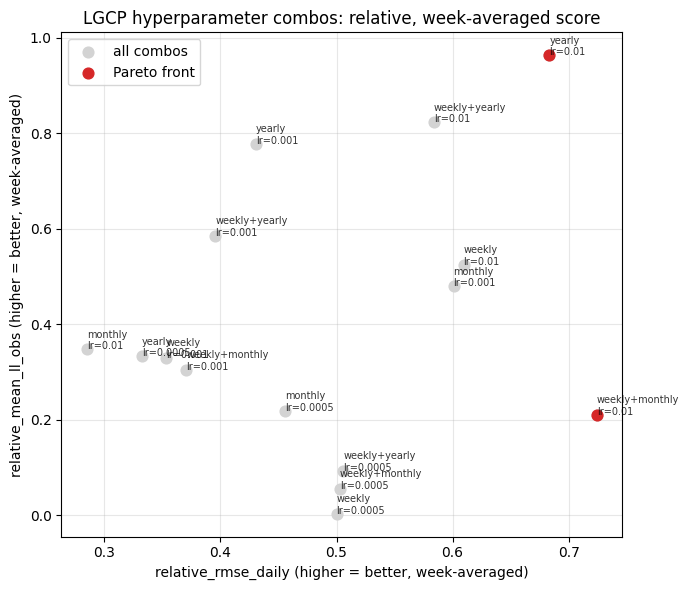

In [7]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.scatter(lgcp_scores_df[score_col_rmse], lgcp_scores_df[score_col_ll], color="lightgray", s=60, label="all combos", zorder=2)
ax.scatter(lgcp_pareto_df[score_col_rmse], lgcp_pareto_df[score_col_ll], color="tab:red", s=60, label="Pareto front", zorder=3)
for _, row in lgcp_scores_df.iterrows():
    ax.annotate(f"{row['kernel']}\nlr={row['lr']}", (row[score_col_rmse], row[score_col_ll]), fontsize=7, alpha=0.8)
ax.set_xlabel(f"{score_col_rmse} (higher = better, week-averaged)")
ax.set_ylabel(f"{score_col_ll} (higher = better, week-averaged)")
ax.set_title("LGCP hyperparameter combos: relative, week-averaged score")
ax.legend()
ax.grid(alpha=0.3)
fig.tight_layout()
fig.savefig(RESULTS_DIR / "lgcp_relative_score_pareto.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 3 — Confirm the winning LGCP configuration at full training length

The search above used a reduced `LGCP_NUM_STEPS_SEARCH` budget. The
winning (kernel, lr) is re-trained here at `LGCP_NUM_STEPS_FINAL` on
*both* weeks (reusing the cached data from Step 1) for the final table.

In [8]:
lgcp_confirm_rows = []
for week in TEST_WEEKS:
    label = week["label"]
    wd = WEEK_DATA[label]
    model_cfg = build_temporal_model_cfg(base_cfg["model"], LGCP_KERNEL_SPECS[BEST_LGCP_KERNEL], wd["t_scaler"], wd["span_days"])

    print(f"Confirming on week '{label}' ({wd['test_start']} .. {wd['test_end']}): "
          f"kernel={BEST_LGCP_KERNEL}  lr={BEST_LGCP_LR}  num_steps={LGCP_NUM_STEPS_FINAL}")
    metrics, elapsed = run_lgcp_combo(
        base_cfg, wd["train_coords"], wd["train_covs"], wd["train_y"],
        wd["test_coords"], wd["test_covs"], wd["test_y"], wd["test_dates"],
        lr=BEST_LGCP_LR, num_mc=LGCP_NUM_MC, num_steps=LGCP_NUM_STEPS_FINAL, model_cfg=model_cfg, seed=SEED,
    )
    if metrics["failed"]:
        raise RuntimeError(
            f"Winning LGCP config failed to converge on week '{label}' at full length "
            "(it succeeded during the shorter search). Consider the runner-up in lgcp_scores_df."
        )
    print(f"  mean_ll_obs={metrics['mean_ll_obs']:.4f}  rmse_daily={metrics['rmse_daily']:.4f}  ({elapsed:.1f}s)")
    lgcp_confirm_rows.append({"method": "LGCP", "week": label, **{k: metrics[k] for k in METRIC_KEYS}})

lgcp_confirm_df = pd.DataFrame(lgcp_confirm_rows)
lgcp_confirm_df.to_csv(RESULTS_DIR / "lgcp_confirmed_results.csv", index=False)
lgcp_confirm_df

Confirming on week 'may' (2025-05-01 .. 2025-05-07): kernel=yearly  lr=0.01  num_steps=5000

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/5000]  loss=691943.5000  ll=-29725.7539  kl=645.5821  (0.1s)


[  5000/5000]  loss=6906.3149  ll=-288.5986  kl=194.7069  (267.3s)
  mean_ll_obs=-0.3930  rmse_daily=10.7634  (267.4s)
Confirming on week 'november' (2025-11-01 .. 2025-11-07): kernel=yearly  lr=0.01  num_steps=5000

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/5000]  loss=34466888.0000  ll=-1075040.6250  kl=497.0159  (0.1s)


[  5000/5000]  loss=13176.6738  ll=-405.2023  kl=185.6659  (241.9s)
  mean_ll_obs=-0.4999  rmse_daily=6.9982  (241.9s)


,method,week,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving
0,LGCP,may,-0.393025,0.284244,0.785790,-6.099065,7.269031,10.763390,0.224878,0.75
1,LGCP,november,-0.499918,0.286813,0.679769,-3.325382,5.672012,6.998157,0.939318,1.00


## Step 4 — Baseline grid searches (same two weeks, same relative-average scoring)

Hyperparameter grids, chosen to be standard/justifiable rather than tuned
(defined in the grids cell at the top):

- **Last-available Poisson**: no continuous hyperparameters — just its two
  prediction modes.
- **Window Poisson GLM**: `poisson_alpha` (L2 regularization) over a
  standard log-spaced grid, x `window_size` (autoregressive context
  length) over short/weekly/biweekly (3/7/14 days).
- **GNN**: `hidden_dim` and `num_layers` over typical small-GCN
  capacities, x `lr` over a standard Adam range.

In [9]:
la_cfg = last_avail.load_config(None)
la_cfg["years"] = YEARS
la_cfg["parquet_path"] = str(PROJECT_ROOT / la_cfg["parquet_path"])

la_rows = []
for week in TEST_WEEKS:
    label, test_start, test_end = week["label"], week["test_start"], week["test_end"]
    for mode in LAST_AVAILABLE_MODES:
        (_, _, _, _, _, test_y, _, df_la) = last_avail.prepare_data(
            la_cfg["parquet_path"], train_fraction=la_cfg["train_fraction"], random_seed=la_cfg["data_seed"],
            split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
            years=YEARS,
        )
        df_la["date"] = pd.to_datetime(df_la["date"])
        train_mask, test_mask = last_avail.make_day_split_masks(
            df=df_la, train_fraction=la_cfg["train_fraction"], random_seed=la_cfg["data_seed"],
            split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
        )
        test_dates = df_la.loc[test_mask, "date"].values
        preds = last_avail.build_last_available_predictions(df=df_la, train_mask=train_mask, test_mask=test_mask, mode=mode)
        metrics = evaluate_metrics(test_y, preds, test_dates)
        print(f"[week={label} mode={mode}] mean_ll_obs={metrics['mean_ll_obs']:.4f}  rmse_daily={metrics['rmse_daily']:.4f}")
        la_rows.append({"week": label, "mode": mode, **metrics})

la_results_df = pd.DataFrame(la_rows)
la_results_df.to_csv(RESULTS_DIR / "last_available_grid_results.csv", index=False)
la_scores_df = compute_relative_scores(la_results_df, week_col="week", group_cols=["mode"], metrics_directions=METRIC_DIRECTIONS)
display(la_scores_df)
best_la_mode = la_scores_df.iloc[0]["mode"]
print(f"Selected last-available mode: {best_la_mode}")

[week=may mode=frozen_train] mean_ll_obs=-1.8278  rmse_daily=21.2872


[week=may mode=one_step_ahead] mean_ll_obs=-2.7974  rmse_daily=15.1186
[week=november mode=frozen_train] mean_ll_obs=-2.7569  rmse_daily=12.7560
[week=november mode=one_step_ahead] mean_ll_obs=-2.2659  rmse_daily=9.0711


,mode,relative_mean_ll_obs,relative_rmse_daily,combined_relative_score,n_weeks_valid
1,one_step_ahead,0.5,1.0,0.75,2
0,frozen_train,0.5,0.0,0.25,2


Selected last-available mode: one_step_ahead


In [10]:
glm_cfg = window_glm.load_config(str(PROJECT_ROOT / BASE_GLM_CONFIG))
glm_cfg["years"] = YEARS
glm_cfg["parquet_path"] = str(PROJECT_ROOT / glm_cfg["parquet_path"])

df_glm_raw = window_glm.load_parquet_years(glm_cfg["parquet_path"], YEARS)
df_glm_raw["date"] = pd.to_datetime(df_glm_raw["date"])

glm_rows = []
for week in TEST_WEEKS:
    label, test_start, test_end = week["label"], week["test_start"], week["test_end"]
    for window_size in GLM_WINDOW_SIZE_GRID:
        cfg_ws = dict(glm_cfg)
        cfg_ws["window_size"] = window_size
        df_win, feature_cols = window_glm.build_window_dataframe(df_glm_raw, cfg_ws)
        train_mask, test_mask = window_glm.make_split_masks(
            dates=df_win["date"], split_strategy="fixed_test_window",
            train_fraction=cfg_ws["train_fraction"], random_seed=cfg_ws["data_seed"],
            test_start_date=test_start, test_end_date=test_end,
        )
        X = df_win[feature_cols].values.astype(np.float32)
        y = df_win[cfg_ws["target_col"]].values.astype(np.float32)
        dts = df_win["date"].values
        X_train, y_train = X[train_mask], y[train_mask]
        X_test, y_test = X[test_mask], y[test_mask]
        test_dates = dts[test_mask]

        scaler = StandardScaler()
        X_train_s = scaler.fit_transform(X_train)
        X_test_s = scaler.transform(X_test)

        for alpha in GLM_ALPHA_GRID:
            model = PoissonRegressor(alpha=alpha, max_iter=cfg_ws["max_iter"])
            model.fit(X_train_s, y_train)
            preds = np.clip(model.predict(X_test_s), 0, None)
            metrics = evaluate_metrics(y_test, preds, test_dates)
            glm_rows.append({"week": label, "window_size": window_size, "poisson_alpha": alpha, **metrics})
    print(f"[week={label}] GLM grid done.")

glm_results_df = pd.DataFrame(glm_rows)
glm_results_df.to_csv(RESULTS_DIR / "glm_grid_results.csv", index=False)
glm_scores_df = compute_relative_scores(glm_results_df, week_col="week", group_cols=["window_size", "poisson_alpha"], metrics_directions=METRIC_DIRECTIONS)
display(glm_scores_df.head(10))
best_glm_row = glm_scores_df.iloc[0]
BEST_GLM_WINDOW_SIZE = int(best_glm_row["window_size"])
BEST_GLM_ALPHA = float(best_glm_row["poisson_alpha"])
print(f"Selected GLM config: window_size={BEST_GLM_WINDOW_SIZE}  poisson_alpha={BEST_GLM_ALPHA}")

[week=may] GLM grid done.


[week=november] GLM grid done.


,window_size,poisson_alpha,relative_mean_ll_obs,relative_rmse_daily,combined_relative_score,n_weeks_valid
10,14,0.0001,1.000000,0.963664,0.981832,2
11,14,0.0010,0.997116,0.957862,0.977489,2
12,14,0.0100,0.969297,0.912102,0.940700,2
0,3,0.0001,0.811876,0.941571,0.876723,2
1,3,0.0010,0.808829,0.936439,0.872634,2
2,3,0.0100,0.782033,0.895403,0.838718,2
5,7,0.0001,0.747563,0.790567,0.769065,2
6,7,0.0010,0.744541,0.785671,0.765106,2
7,7,0.0100,0.711834,0.740079,0.725956,2
13,14,0.1000,0.783846,0.642631,0.713239,2


Selected GLM config: window_size=14  poisson_alpha=0.0001


In [11]:
gnn_cfg = gnn_mod.load_config(str(PROJECT_ROOT / BASE_GNN_CONFIG))
gnn_cfg["years"] = YEARS
gnn_cfg["parquet_path"] = str(PROJECT_ROOT / gnn_cfg["parquet_path"])
device = torch.device(gnn_cfg.get("device", "cpu"))

df_gnn = gnn_mod.load_parquet_years(gnn_cfg["parquet_path"], YEARS)
df_gnn["date"] = pd.to_datetime(df_gnn["date"])
df_feat, feature_cols = gnn_mod.build_node_features(df_gnn, gnn_cfg)
X, Y, dates, cell_coords = gnn_mod.build_graph_tensors(df_feat, feature_cols, gnn_cfg["target_col"])
n_dates, n_cells, n_features = X.shape

adj = gnn_mod.build_grid_adjacency(
    cell_coords[["longitude", "latitude"]].to_numpy(), connectivity=gnn_cfg.get("adjacency", "queen")
)
adj_norm = gnn_mod.normalize_adjacency(adj)
adj_norm_t = torch.tensor(adj_norm, dtype=torch.float32, device=device)

gnn_rows = []
for week in TEST_WEEKS:
    label, test_start, test_end = week["label"], week["test_start"], week["test_end"]

    train_mask, test_mask = gnn_mod.make_day_split_masks(
        df=pd.DataFrame({"date": dates}), train_fraction=gnn_cfg["train_fraction"], random_seed=gnn_cfg["data_seed"],
        split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
    )
    X_train, Y_train = X[train_mask], Y[train_mask]
    X_test, Y_test = X[test_mask], Y[test_mask]
    dates_test = dates[test_mask]

    scaler = StandardScaler()
    scaler.fit(X_train.reshape(-1, n_features))
    X_train_model = scaler.transform(X_train.reshape(-1, n_features)).reshape(X_train.shape)
    X_test_model = scaler.transform(X_test.reshape(-1, n_features)).reshape(X_test.shape)

    X_train_t = torch.tensor(X_train_model, dtype=torch.float32, device=device)
    Y_train_t = torch.tensor(Y_train, dtype=torch.float32, device=device)
    X_test_t = torch.tensor(X_test_model, dtype=torch.float32, device=device)

    for hidden_dim, num_layers, lr in itertools.product(GNN_HIDDEN_DIM_GRID, GNN_NUM_LAYERS_GRID, GNN_LR_GRID):
        torch.manual_seed(SEED)
        model = gnn_mod.SpatioTemporalGNN(
            in_dim=n_features, hidden_dim=hidden_dim, num_layers=num_layers, dropout=gnn_cfg["dropout"],
        ).to(device)
        optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=gnn_cfg["weight_decay"])

        model.train()
        for epoch in range(1, int(gnn_cfg["num_epochs"]) + 1):
            optimizer.zero_grad()
            rate_train = model(X_train_t, adj_norm_t)
            loss = gnn_mod.poisson_nll(rate_train, Y_train_t)
            loss.backward()
            optimizer.step()

        model.eval()
        with torch.no_grad():
            rate_test = model(X_test_t, adj_norm_t).cpu().numpy()
        rate_test = np.clip(rate_test, 0, None)

        y_test_flat = Y_test.reshape(-1)
        rate_test_flat = rate_test.reshape(-1)
        test_dates_flat = np.repeat(dates_test, n_cells)
        metrics = evaluate_metrics(y_test_flat, rate_test_flat, test_dates_flat)
        gnn_rows.append({"week": label, "hidden_dim": hidden_dim, "num_layers": num_layers, "lr": lr, **metrics})
    print(f"[week={label}] GNN grid done.")

gnn_results_df = pd.DataFrame(gnn_rows)
gnn_results_df.to_csv(RESULTS_DIR / "gnn_grid_results.csv", index=False)
gnn_scores_df = compute_relative_scores(gnn_results_df, week_col="week", group_cols=["hidden_dim", "num_layers", "lr"], metrics_directions=METRIC_DIRECTIONS)
display(gnn_scores_df.head(10))
best_gnn_row = gnn_scores_df.iloc[0]
BEST_GNN_HIDDEN_DIM = int(best_gnn_row["hidden_dim"])
BEST_GNN_NUM_LAYERS = int(best_gnn_row["num_layers"])
BEST_GNN_LR = float(best_gnn_row["lr"])
print(f"Selected GNN config: hidden_dim={BEST_GNN_HIDDEN_DIM}  num_layers={BEST_GNN_NUM_LAYERS}  lr={BEST_GNN_LR}")

Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']


[week=may] GNN grid done.


[week=november] GNN grid done.


,hidden_dim,num_layers,lr,relative_mean_ll_obs,relative_rmse_daily,combined_relative_score,n_weeks_valid
9,32,2,0.010,0.712880,0.833247,0.773064,2
3,16,2,0.010,0.563784,0.827269,0.695526,2
15,64,2,0.010,0.867416,0.456982,0.662199,2
13,64,1,0.010,0.510438,0.631181,0.570810,2
11,32,3,0.010,0.512921,0.610142,0.561532,2
17,64,3,0.010,0.671214,0.386755,0.528985,2
1,16,1,0.010,0.453465,0.501642,0.477553,2
4,16,3,0.001,0.105659,0.794011,0.449835,2
14,64,2,0.001,0.297191,0.592706,0.444948,2
7,32,1,0.010,0.398235,0.482364,0.440299,2


Selected GNN config: hidden_dim=32  num_layers=2  lr=0.01


## Final comparison table

In [12]:
baseline_rows = []
for row in la_results_df[la_results_df["mode"] == best_la_mode].to_dict("records"):
    baseline_rows.append({"method": "Last Available Poisson", "week": row["week"], **{k: row[k] for k in METRIC_KEYS}})
for row in glm_results_df[
    (glm_results_df["window_size"] == BEST_GLM_WINDOW_SIZE) & (glm_results_df["poisson_alpha"] == BEST_GLM_ALPHA)
].to_dict("records"):
    baseline_rows.append({"method": "Window Poisson GLM", "week": row["week"], **{k: row[k] for k in METRIC_KEYS}})
for row in gnn_results_df[
    (gnn_results_df["hidden_dim"] == BEST_GNN_HIDDEN_DIM)
    & (gnn_results_df["num_layers"] == BEST_GNN_NUM_LAYERS)
    & (gnn_results_df["lr"] == BEST_GNN_LR)
].to_dict("records"):
    baseline_rows.append({"method": "GNN", "week": row["week"], **{k: row[k] for k in METRIC_KEYS}})

final_by_week_df = pd.concat([lgcp_confirm_df, pd.DataFrame(baseline_rows)], ignore_index=True)
final_by_week_df.to_csv(RESULTS_DIR / "final_comparison_by_week.csv", index=False)

hyperparameters = {
    "LGCP": f"kernel={BEST_LGCP_KERNEL}, lr={BEST_LGCP_LR}, num_mc={LGCP_NUM_MC}, num_steps={LGCP_NUM_STEPS_FINAL}",
    "Window Poisson GLM": f"window_size={BEST_GLM_WINDOW_SIZE}, poisson_alpha={BEST_GLM_ALPHA}",
    "GNN": f"hidden_dim={BEST_GNN_HIDDEN_DIM}, num_layers={BEST_GNN_NUM_LAYERS}, lr={BEST_GNN_LR}",
    "Last Available Poisson": f"mode={best_la_mode}",
}

final_avg_df = final_by_week_df.groupby("method")[METRIC_KEYS].mean()
final_avg_df.insert(0, "hyperparameters", final_avg_df.index.map(hyperparameters))
final_avg_df = final_avg_df.loc[["LGCP", "Window Poisson GLM", "GNN", "Last Available Poisson"]]
final_avg_df.to_csv(RESULTS_DIR / "final_comparison_avg.csv")

print("Per-week detail:")
display(final_by_week_df.set_index(["method", "week"]))

print(f"\nWeek-averaged final comparison (weeks: {[w['label'] for w in TEST_WEEKS]}):")
print(f"All intermediate results + this table saved under: {RESULTS_DIR}\n")
final_avg_df

Per-week detail:


mean_ll_obs   mae_obs  rmse_obs  \
method                 week                                        
LGCP                   may         -0.393025  0.284244  0.785790   
                       november    -0.499918  0.286813  0.679769   
Last Available Poisson may         -2.797441  0.285714  0.938332   
                       november    -2.265950  0.285714  0.732423   
Window Poisson GLM     may         -0.484117  0.291235  0.783561   
                       november    -0.570229  0.383867  0.752295   
GNN                    may         -0.421341  0.265900  0.756374   
                       november    -0.541930  0.327014  0.717327   

                                 mean_ll_daily  mae_daily  rmse_daily  \
method                 week                                             
LGCP                   may           -6.099065   7.269031   10.763390   
                       november      -3.325382   5.672012    6.998157   
Last Available Poisson may          -70.301578  12.285714   15.118579   
                       november     -64.801121   6.857143    9.071147   
Window Poisson GLM     may           -6.178605   7.177548   10.760359   
                       november      -2.358670   3.341280    4.556091   
GNN                    may           -5.384786   6.841281    9.461209   
                       november      -1.986969   1.063812    1.435756   

                                 daily_delta_corr  \
method                 week                         
LGCP                   may               0.224878   
                       november          0.939318   
Last Available Poisson may              -0.029702   
                       november          0.146487   
Window Poisson GLM     may               0.392711   
                       november          0.931043   
GNN                    may               0.277140   
                       november          0.976629   

                                 daily_direction_accuracy_moving  
method                 week                                       
LGCP                   may                                  0.75  
                       november                             1.00  
Last Available Poisson may                                  0.25  
                       november                             0.25  
Window Poisson GLM     may                                  0.75  
                       november                             1.00  
GNN                    may                                  1.00  
                       november                             1.00


Week-averaged final comparison (weeks: ['may', 'november']):
All intermediate results + this table saved under: /home/rdoz/PhD/AIPS/reports/paper/lgcp_two_week_2025_05_11



,hyperparameters,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving
method,,,,,,,,,
LGCP,"kernel=yearly, lr=0.01, num_mc=64, num_steps=5000",-0.446472,0.285528,0.732779,-4.712224,6.470521,8.880774,0.582098,0.875
Window Poisson GLM,"window_size=14, poisson_alpha=0.0001",-0.527173,0.337551,0.767928,-4.268638,5.259414,7.658225,0.661877,0.875
GNN,"hidden_dim=32, num_layers=2, lr=0.01",-0.481636,0.296457,0.736850,-3.685878,3.952546,5.448483,0.626885,1.000
Last Available Poisson,mode=one_step_ahead,-2.531695,0.285714,0.835377,-67.551349,9.571429,12.094863,0.058393,0.250


**Notes for the paper writeup**

- All 4 methods are evaluated on the identical two test weeks and trained
  on the identical `years=[2024, 2025]` data available before each week.
- Every method's hyperparameters were chosen the same way: grid search
  both weeks, score by the relative (min-max normalized per week) average
  of `(mean_ll_obs, rmse_daily)`, keep only combos that converged on both
  weeks, take the top scorer.
- `final_comparison_by_week.csv` has the per-week breakdown;
  `final_comparison_avg.csv` is the headline week-averaged table above.
- `lgcp_relative_score_pareto.png` shows the LGCP kernel/lr trade-off
  surface for the appendix/supplementary material.

**Update:** the covariate enrichment found here is now folded directly into `LGCP_COVARIATE_COLS` in the grids cell at the top, so Step 1's kernel/lr search itself already benefits from it -- this section is kept as the historical record of why that decision was made. Re-running it below now compares the (now-default) enriched set against itself, so both rows should come out identical -- an implicit confirmation the override took effect, not a bug.

## Step 5 — Closing the daily-metric gap with GNN

LGCP wins on `mean_ll_obs` (the selection metric) but loses to GNN on every
daily-aggregate metric. The GNN and LGCP currently use the *same*
`covariate_cols` (`cell_roll_mean_7` / `daily_total_lag_*` are disabled in
both `config/15_gnn.yaml` and `config/train_basic_lgcp_multi_kernel.yaml`),
so that's not the cause -- it's architectural: the LGCP's rate is
`exp(alpha + beta @ covariates + f_spatial + f_temporal)`, i.e. a single
*global linear* covariate effect shared across every cell/day, plus smooth
additive GP corrections. The GNN's graph convolutions let it learn
cell- and day-specific nonlinear combinations of the same features,
including same-day signal from neighboring cells -- exactly what
daily-aggregate metrics are sensitive to (correlated same-day misses
across many cells compound when summed, even if each cell's own
log-likelihood looks fine in isolation).

Cheapest thing to test: `daily_total_lag_1`, `daily_total_lag_7`,
`daily_total_roll_mean_7`, and `cell_roll_mean_7` are already computed by
the LGCP's `lag_features` block but never added to `covariate_cols`. They
give the model a direct linear proxy for "today's expected regional
total" from recent history, which should help daily calibration even
within the linear-covariate structure. Tested here by re-training the
already-selected winning (kernel, lr) with these four features added --
overridden locally in this notebook, not written back to the shared
config, since this is a diagnostic, not (yet) a decision to change the
official run.

In [13]:
extra_lag_cols = ["cell_roll_mean_7", "daily_total_lag_1", "daily_total_lag_7", "daily_total_roll_mean_7"]
enriched_covariate_cols = list(base_cfg["covariate_cols"]) + [
    c for c in extra_lag_cols if c not in base_cfg["covariate_cols"]
]
print(f"Original covariate_cols: {base_cfg['covariate_cols']}")
print(f"Enriched covariate_cols: {enriched_covariate_cols}")

lgcp_enriched_rows = []
for week in TEST_WEEKS:
    label, test_start, test_end = week["label"], week["test_start"], week["test_end"]

    (
        train_coords, train_covs, train_y,
        test_coords, test_covs, test_y,
        scalers, df,
    ) = train_lgcp.prepare_data(
        base_cfg["parquet_path"],
        train_fraction=base_cfg["train_fraction"],
        random_seed=base_cfg["data_seed"],
        split_strategy="fixed_test_window",
        covariate_cols=enriched_covariate_cols,
        test_start_date=test_start,
        test_end_date=test_end,
        lag_features=base_cfg.get("lag_features"),
        years=YEARS,
    )
    _, test_mask = train_lgcp.make_day_split_masks(
        df=df, train_fraction=base_cfg["train_fraction"], random_seed=base_cfg["data_seed"],
        split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
    )
    test_dates = df.loc[test_mask, "date"].values
    span_days = (df["date"].max() - df["date"].min()).days
    t_scaler = scalers["t_scaler"]
    model_cfg = build_temporal_model_cfg(base_cfg["model"], LGCP_KERNEL_SPECS[BEST_LGCP_KERNEL], t_scaler, span_days)

    print(f"\nTraining enriched-covariate LGCP on week '{label}' ({test_start} .. {test_end}): "
          f"kernel={BEST_LGCP_KERNEL}  lr={BEST_LGCP_LR}  num_steps={LGCP_NUM_STEPS_FINAL}")
    metrics, elapsed = run_lgcp_combo(
        base_cfg, train_coords, train_covs, train_y,
        test_coords, test_covs, test_y, test_dates,
        lr=BEST_LGCP_LR, num_mc=LGCP_NUM_MC, num_steps=LGCP_NUM_STEPS_FINAL, model_cfg=model_cfg, seed=SEED,
    )
    print(f"  mean_ll_obs={metrics['mean_ll_obs']:.4f}  rmse_daily={metrics['rmse_daily']:.4f}  ({elapsed:.1f}s)")
    lgcp_enriched_rows.append({"method": "LGCP (+ daily-total lag features)", "week": label, **{k: metrics[k] for k in METRIC_KEYS}})

lgcp_enriched_df = pd.DataFrame(lgcp_enriched_rows)
lgcp_enriched_df.to_csv(RESULTS_DIR / "lgcp_enriched_covariates_results.csv", index=False)

comparison_df = pd.concat(
    [
        lgcp_confirm_df,
        lgcp_enriched_df,
        final_by_week_df[final_by_week_df["method"] == "GNN"],
    ],
    ignore_index=True,
)
print("\nLGCP (original) vs LGCP (+ daily-total lag features) vs GNN, per week:")
display(comparison_df.set_index(["method", "week"])[["mean_ll_obs", "mean_ll_daily", "mae_daily", "rmse_daily"]])

comparison_avg_df = comparison_df.groupby("method")[METRIC_KEYS].mean()
comparison_avg_df = comparison_avg_df.loc[["LGCP", "LGCP (+ daily-total lag features)", "GNN"]]
comparison_avg_df.to_csv(RESULTS_DIR / "lgcp_daily_metric_experiment.csv")
print("\nWeek-averaged:")
comparison_avg_df

Original covariate_cols: ['chl', 'thetao', 'fishing_block', 'is_holiday', 'is_weekend', 'cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']
Enriched covariate_cols: ['chl', 'thetao', 'fishing_block', 'is_holiday', 'is_weekend', 'cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

Training enriched-covariate LGCP on week 'may' (2025-05-01 .. 2025-05-07): kernel=yearly  lr=0.01  num_steps=5000

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/5000]  loss=691943.5000  ll=-29725.7539  kl=645.5821  (0.0s)


[  5000/5000]  loss=6906.3149  ll=-288.5986  kl=194.7069  (255.8s)
  mean_ll_obs=-0.3930  rmse_daily=10.7634  (255.8s)
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

Training enriched-covariate LGCP on week 'november' (2025-11-01 .. 2025-11-07): kernel=yearly  lr=0.01  num_steps=5000

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/5000]  loss=34466888.0000  ll=-1075040.6250  kl=497.0159  (0.0s)


[  5000/5000]  loss=13176.6738  ll=-405.2023  kl=185.6659  (246.2s)
  mean_ll_obs=-0.4999  rmse_daily=6.9982  (246.2s)

LGCP (original) vs LGCP (+ daily-total lag features) vs GNN, per week:


mean_ll_obs  mean_ll_daily  \
method                            week                                   
LGCP                              may         -0.393025      -6.099065   
                                  november    -0.499918      -3.325382   
LGCP (+ daily-total lag features) may         -0.393025      -6.099065   
                                  november    -0.499918      -3.325382   
GNN                               may         -0.421341      -5.384786   
                                  november    -0.541930      -1.986969   

                                            mae_daily  rmse_daily  
method                            week                             
LGCP                              may        7.269031   10.763390  
                                  november   5.672012    6.998157  
LGCP (+ daily-total lag features) may        7.269031   10.763390  
                                  november   5.672012    6.998157  
GNN                               may        6.841281    9.461209  
                                  november   1.063812    1.435756


Week-averaged:


,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving
method,,,,,,,,
LGCP,-0.446472,0.285528,0.732779,-4.712224,6.470521,8.880774,0.582098,0.875
LGCP (+ daily-total lag features),-0.446472,0.285528,0.732779,-4.712224,6.470521,8.880774,0.582098,0.875
GNN,-0.481636,0.296457,0.736850,-3.685878,3.952546,5.448483,0.626885,1.000


## Step 6 — Does a more flexible spatial kernel help?

Every run so far used a single RBF spatial kernel with a fixed, never-tuned
lengthscale -- only the temporal kernel and learning rate were varied in
Step 1. Since the daily-aggregate gap with GNN is about correlated errors
across many cells at once, spatial rigidity is a plausible contributor
alongside the temporal structure. Staged after Step 1/2 (holding the
winning `BEST_LGCP_KERNEL`, `BEST_LGCP_LR`, and `covariate_cols` fixed)
rather than crossed into the main grid, to keep compute bounded.

Six spatial-kernel variants are compared:

- `rbf_fixed_lengthscale_{0.05, 0.1, 0.2, 0.35}` -- the current default
  structure (fixed, non-trainable lengthscale) at 4 different scales
  (`LGCP_SPATIAL_LENGTHSCALE_GRID`), from tight/local to broad/regional.
- `rbf_trainable_lengthscale` -- same RBF, but the lengthscale is let the
  optimizer choose it instead of pinning it.
- `rational_quadratic` -- a scale-mixture of RBFs (already scaffolded as a
  commented-out option in the config), which can represent both local
  hotspots and broader regional smoothness at once instead of one fixed
  scale.

In [14]:
SPATIAL_KERNEL_SPECS = {}
for ls in LGCP_SPATIAL_LENGTHSCALE_GRID:
    SPATIAL_KERNEL_SPECS[f"rbf_fixed_lengthscale_{ls}"] = {
        "type": "RBF",
        "hyperparameters": {"lengthscale": ls, "variance": 2.0},
        "trainable": {"lengthscale": False, "variance": True},
    }
SPATIAL_KERNEL_SPECS["rbf_trainable_lengthscale"] = {
    "type": "RBF",
    "hyperparameters": {"lengthscale": 0.1, "variance": 2.0},
    "trainable": {"lengthscale": True, "variance": True},
}
SPATIAL_KERNEL_SPECS["rational_quadratic"] = {
    "type": "RationalQuadratic",
    "hyperparameters": {"lengthscale": 1.2, "variance": 0.35, "alpha": 0.8},
    "trainable": {"lengthscale": True, "variance": True, "alpha": False},
}

print(f"covariate_cols used for this step: {base_cfg['covariate_cols']}")

spatial_rows = []
for spatial_name, spatial_spec in SPATIAL_KERNEL_SPECS.items():
    for week in TEST_WEEKS:
        label, test_start, test_end = week["label"], week["test_start"], week["test_end"]

        (
            train_coords, train_covs, train_y,
            test_coords, test_covs, test_y,
            scalers, df,
        ) = train_lgcp.prepare_data(
            base_cfg["parquet_path"],
            train_fraction=base_cfg["train_fraction"],
            random_seed=base_cfg["data_seed"],
            split_strategy="fixed_test_window",
            covariate_cols=base_cfg["covariate_cols"],
            test_start_date=test_start,
            test_end_date=test_end,
            lag_features=base_cfg.get("lag_features"),
            years=YEARS,
        )
        _, test_mask = train_lgcp.make_day_split_masks(
            df=df, train_fraction=base_cfg["train_fraction"], random_seed=base_cfg["data_seed"],
            split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
        )
        test_dates = df.loc[test_mask, "date"].values
        span_days = (df["date"].max() - df["date"].min()).days
        t_scaler = scalers["t_scaler"]

        model_cfg = build_temporal_model_cfg(base_cfg["model"], LGCP_KERNEL_SPECS[BEST_LGCP_KERNEL], t_scaler, span_days)
        model_cfg["spatial_kernels"] = [copy.deepcopy(spatial_spec)]

        print(f"\nTraining spatial={spatial_name} on week '{label}' ({test_start} .. {test_end}) ...")
        metrics, elapsed = run_lgcp_combo(
            base_cfg, train_coords, train_covs, train_y,
            test_coords, test_covs, test_y, test_dates,
            lr=BEST_LGCP_LR, num_mc=LGCP_NUM_MC, num_steps=LGCP_NUM_STEPS_FINAL, model_cfg=model_cfg, seed=SEED,
        )
        print(f"  mean_ll_obs={metrics['mean_ll_obs']:.4f}  rmse_daily={metrics['rmse_daily']:.4f}  ({elapsed:.1f}s)")
        spatial_rows.append({"spatial_kernel": spatial_name, "week": label, **metrics})

spatial_results_df = pd.DataFrame(spatial_rows)
spatial_results_df.to_csv(RESULTS_DIR / "lgcp_spatial_kernel_results.csv", index=False)

spatial_scores_df = compute_relative_scores(
    spatial_results_df, week_col="week", group_cols=["spatial_kernel"], metrics_directions=METRIC_DIRECTIONS
)
print("\nSpatial kernel variants ranked by relative, week-averaged score:")
display(spatial_scores_df)

spatial_avg_df = spatial_results_df.groupby("spatial_kernel")[METRIC_KEYS].mean()
spatial_avg_df.to_csv(RESULTS_DIR / "lgcp_spatial_kernel_avg.csv")
print("\nWeek-averaged metrics per spatial kernel:")
spatial_avg_df

covariate_cols used for this step: ['chl', 'thetao', 'fishing_block', 'is_holiday', 'is_weekend', 'cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

Training spatial=rbf_fixed_lengthscale_0.05 on week 'may' (2025-05-01 .. 2025-05-07) ...

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False


[     1/5000]  loss=691795.0625  ll=-29719.3750  kl=645.4464  (0.0s)


[  5000/5000]  loss=7593.1831  ll=-321.7643  kl=110.2790  (249.0s)
  mean_ll_obs=-0.4104  rmse_daily=10.7834  (249.1s)
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

Training spatial=rbf_fixed_lengthscale_0.05 on week 'november' (2025-11-01 .. 2025-11-07) ...

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False
[     1/5000]  loss=34847840.0000  ll=-1086923.0000  kl=496.9321  (0.1s)


[  5000/5000]  loss=13659.3398  ll=-422.3499  kl=118.5716  (255.5s)
  mean_ll_obs=-0.5199  rmse_daily=5.5471  (255.5s)
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

Training spatial=rbf_fixed_lengthscale_0.1 on week 'may' (2025-05-01 .. 2025-05-07) ...

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False


[     1/5000]  loss=691943.5000  ll=-29725.7539  kl=645.5821  (0.1s)


...

[     1/5000]  loss=34018.8672  ll=-856.9434  kl=6544.7954  (0.1s)


[  5000/5000]  loss=13143.2441  ll=-399.9444  kl=320.8081  (267.5s)
  mean_ll_obs=-0.4689  rmse_daily=6.7429  (267.6s)

Spatial kernel variants ranked by relative, week-averaged score:


,spatial_kernel,relative_mean_ll_obs,relative_rmse_daily,combined_relative_score,n_weeks_valid
5,rbf_trainable_lengthscale,0.500000,0.947734,0.723867,2
0,rational_quadratic,0.890877,0.438143,0.664510,2
1,rbf_fixed_lengthscale_0.05,0.448091,0.805788,0.626940,2
2,rbf_fixed_lengthscale_0.1,0.700908,0.551001,0.625955,2
4,rbf_fixed_lengthscale_0.35,0.545464,0.500000,0.522732,2
3,rbf_fixed_lengthscale_0.2,0.230477,0.337083,0.283780,2



Week-averaged metrics per spatial kernel:


,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving
spatial_kernel,,,,,,,,
rational_quadratic,-0.436383,0.297274,0.724417,-5.305357,7.667739,9.912555,0.667249,0.875
rbf_fixed_lengthscale_0.05,-0.465134,0.282373,0.731757,-4.394335,5.706915,8.165292,0.585422,0.750
rbf_fixed_lengthscale_0.1,-0.446472,0.285528,0.732779,-4.712224,6.470521,8.880774,0.582098,0.875
rbf_fixed_lengthscale_0.2,-0.489710,0.344847,0.999885,-6.024445,8.349209,11.578497,0.610133,0.875
rbf_fixed_lengthscale_0.35,-0.456373,0.281431,0.707089,-4.760080,6.922508,8.862270,0.660413,0.875
rbf_trainable_lengthscale,-0.457446,0.306840,0.768197,-4.362737,6.017504,7.829838,0.642533,0.875


## Step 8 — Separable (product) vs. additive (sum) space-time kernel

`src/models/lgcp.py` combined the spatial and temporal kernel matrices as
`Ks * Kt` (a Hadamard product), hardcoded -- the standard *separable*
covariance in spatio-temporal statistics. Separable means the spatial
correlation pattern is identical at every time point (and vice versa); it
cannot represent genuine space-time interaction, which is a plausible
contributor to the daily-aggregate gap with GNN.

Correction from the chat: summing instead of multiplying (`Ks + Kt`) is
NOT a fix for that -- it corresponds to `f(s, t) = f_spatial(s) +
f_temporal(t)`, a purely additive model with *zero* space-time coupling,
so it should be less able to capture joint effects, not more. Tested here
anyway for the record: `src/models/lgcp.py` now supports a
`kernel_config["spacetime_composition"]` switch (`"product"` default,
unchanged behavior; `"sum"` new), and both are compared on the winning
temporal kernel/lr/spatial-kernel/covariates from Steps 5-6. `"product"`
here should reproduce Step 5's numbers, as a sanity check that the new
code path is equivalent to the old hardcoded one.

In [15]:
SPACETIME_COMPOSITIONS = ["product", "sum"]
# "product" is the current default (Ks * Kt, separable) -- included here as
# a sanity check, should reproduce the Step 5 enriched-covariate numbers.
# "sum" (Ks + Kt) removes ALL space-time coupling (pure additive main
# effects); theory says this should do *worse*, not better -- tested for
# the record rather than as an expected fix.

spatial_kernel_spec = base_cfg["model"]["spatial_kernels"][0]  # unchanged from Step 6's conclusion

spacetime_rows = []
for composition in SPACETIME_COMPOSITIONS:
    for week in TEST_WEEKS:
        label, test_start, test_end = week["label"], week["test_start"], week["test_end"]

        (
            train_coords, train_covs, train_y,
            test_coords, test_covs, test_y,
            scalers, df,
        ) = train_lgcp.prepare_data(
            base_cfg["parquet_path"],
            train_fraction=base_cfg["train_fraction"],
            random_seed=base_cfg["data_seed"],
            split_strategy="fixed_test_window",
            covariate_cols=base_cfg["covariate_cols"],
            test_start_date=test_start,
            test_end_date=test_end,
            lag_features=base_cfg.get("lag_features"),
            years=YEARS,
        )
        _, test_mask = train_lgcp.make_day_split_masks(
            df=df, train_fraction=base_cfg["train_fraction"], random_seed=base_cfg["data_seed"],
            split_strategy="fixed_test_window", test_start_date=test_start, test_end_date=test_end,
        )
        test_dates = df.loc[test_mask, "date"].values
        span_days = (df["date"].max() - df["date"].min()).days
        t_scaler = scalers["t_scaler"]

        model_cfg = build_temporal_model_cfg(base_cfg["model"], LGCP_KERNEL_SPECS[BEST_LGCP_KERNEL], t_scaler, span_days)
        model_cfg["spatial_kernels"] = [copy.deepcopy(spatial_kernel_spec)]

        run_cfg = dict(base_cfg)
        run_cfg["model"] = model_cfg
        run_cfg["kernel_config"] = train_lgcp.normalize_kernel_config(run_cfg)
        run_cfg["kernel_config"]["spacetime_composition"] = composition
        run_cfg["lr"] = BEST_LGCP_LR
        run_cfg["num_mc"] = LGCP_NUM_MC
        run_cfg["num_steps"] = LGCP_NUM_STEPS_FINAL
        run_cfg["log_every"] = LGCP_NUM_STEPS_FINAL
        m_inducing = min(run_cfg["M_inducing"], train_coords.shape[0])

        train_lgcp.set_seeds(SEED)
        model = train_lgcp.SparseLGCP(
            train_coords, train_covs, train_y,
            kernel_config=run_cfg["kernel_config"],
            M_inducing=m_inducing,
            device=run_cfg["device"],
            np_seed=SEED,
        )
        train_lgcp.configure_log_noise(model, run_cfg)

        print(f"\nTraining spacetime_composition={composition} on week '{label}' ({test_start} .. {test_end}) ...")
        t0 = time.time()
        try:
            train_lgcp.train(model, run_cfg)
            rate_mean, _, _ = model.predict_rate(
                test_coords, test_covs, num_samples=run_cfg.get("num_pred_samples", 200)
            )
            metrics = evaluate_metrics(test_y, rate_mean, test_dates)
            failed = False
        except RuntimeError as e:
            print(f"    !! training failed ({type(e).__name__}: {e})")
            metrics = {k: float("nan") for k in METRIC_KEYS}
            failed = True
        elapsed = time.time() - t0

        print(f"  mean_ll_obs={metrics['mean_ll_obs']:.4f}  rmse_daily={metrics['rmse_daily']:.4f}  ({elapsed:.1f}s)")
        spacetime_rows.append({"spacetime_composition": composition, "week": label, "failed": failed, **metrics})

spacetime_results_df = pd.DataFrame(spacetime_rows)
spacetime_results_df.to_csv(RESULTS_DIR / "lgcp_spacetime_composition_results.csv", index=False)

spacetime_valid_df = spacetime_results_df[~spacetime_results_df["failed"]]
spacetime_scores_df = compute_relative_scores(
    spacetime_valid_df, week_col="week", group_cols=["spacetime_composition"], metrics_directions=METRIC_DIRECTIONS
)
print("\nspacetime_composition variants ranked by relative, week-averaged score:")
display(spacetime_scores_df)

spacetime_avg_df = spacetime_valid_df.groupby("spacetime_composition")[METRIC_KEYS].mean()
spacetime_avg_df.to_csv(RESULTS_DIR / "lgcp_spacetime_composition_avg.csv")
print("\nWeek-averaged metrics per spacetime_composition:")
spacetime_avg_df

Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False

Training spacetime_composition=product on week 'may' (2025-05-01 .. 2025-05-07) ...
[     1/5000]  loss=691943.5000  ll=-29725.7539  kl=645.5821  (0.1s)


[  5000/5000]  loss=6906.3149  ll=-288.5986  kl=194.7069  (254.5s)
  mean_ll_obs=-0.3930  rmse_daily=10.7634  (254.5s)
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False

Training spacetime_composition=product on week 'november' (2025-11-01 .. 2025-11-07) ...
[     1/5000]  loss=34466888.0000  ll=-1075040.6250  kl=497.0159  (0.0s)


[  5000/5000]  loss=13176.6738  ll=-405.2023  kl=185.6659  (243.4s)
  mean_ll_obs=-0.4999  rmse_daily=6.9982  (243.4s)
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False

Training spacetime_composition=sum on week 'may' (2025-05-01 .. 2025-05-07) ...
[     1/5000]  loss=65725.7969  ll=-848.2515  kl=45998.9766  (0.0s)


[  5000/5000]  loss=7731.3335  ll=-324.1028  kl=194.0437  (283.5s)
  mean_ll_obs=-0.4001  rmse_daily=10.1059  (283.6s)
Generated lag features: ['cell_lag_1', 'cell_lag_7', 'cell_roll_mean_7', 'daily_total_lag_1', 'daily_total_lag_7', 'daily_total_roll_mean_7']

=== Kernel noise configuration ===
noise_var: 0.00100000
trainable: False

Training spacetime_composition=sum on week 'november' (2025-11-01 .. 2025-11-07) ...


[     1/5000]  loss=68703.5703  ll=-714.8491  kl=45785.1211  (0.1s)


[  5000/5000]  loss=13834.1426  ll=-425.0162  kl=207.8907  (263.8s)
  mean_ll_obs=-0.5546  rmse_daily=4.6857  (263.8s)

spacetime_composition variants ranked by relative, week-averaged score:


,spacetime_composition,relative_mean_ll_obs,relative_rmse_daily,combined_relative_score,n_weeks_valid
0,product,1.0,0.0,0.5,2
1,sum,0.0,1.0,0.5,2



Week-averaged metrics per spacetime_composition:


,mean_ll_obs,mae_obs,rmse_obs,mean_ll_daily,mae_daily,rmse_daily,daily_delta_corr,daily_direction_accuracy_moving
spacetime_composition,,,,,,,,
product,-0.446472,0.285528,0.732779,-4.712224,6.470521,8.880774,0.582098,0.875
sum,-0.477311,0.295517,0.733772,-4.044444,5.267331,7.395794,0.593564,0.875
